# Fraud EDA — PaySim Mobile Money Transactions

Data pulled live from PostgreSQL (`finsight.transactions`, loaded via `src/db_connect.py`) — not from the raw CSV.
Explores missingness, key numeric distributions, feature correlations, and fraud rate by transaction type and balance-drain pattern.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from db_connect import get_engine
from eda_utils import plot_distribution, plot_missing_map, plot_correlation_heatmap, sequential_shades

%matplotlib inline
pd.set_option("display.max_columns", 50)

engine = get_engine()
total_txns = pd.read_sql("SELECT COUNT(*) AS n FROM finsight.transactions", engine)["n"][0]
total_fraud = pd.read_sql("SELECT SUM(is_fraud) AS n FROM finsight.transactions", engine)["n"][0]
print(f"finsight.transactions total rows: {total_txns:,}")
print(f"Total fraudulent transactions: {total_fraud:,} ({100*total_fraud/total_txns:.4f}% of all transactions)")

finsight.transactions total rows: 6,362,620
Total fraudulent transactions: 8,213 (0.1291% of all transactions)


## Missing values

Sampled ~1% of transactions.

Sample size: 65,168 rows


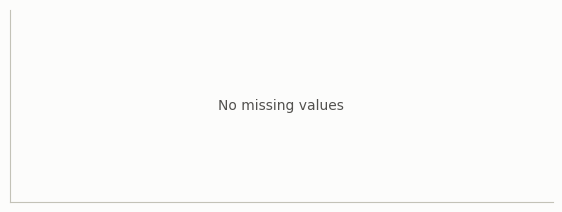

In [2]:
NUMERIC_COLS = ["step", "amount", "sender_bal_before", "sender_bal_after",
                "receiver_bal_before", "receiver_bal_after", "is_fraud"]

sample_df = pd.read_sql(
    f"SELECT txn_type, {', '.join(NUMERIC_COLS)} FROM finsight.transactions TABLESAMPLE SYSTEM (1)",
    engine,
)
print(f"Sample size: {len(sample_df):,} rows")

fig, ax = plt.subplots(figsize=(7, 2.5))
plot_missing_map(sample_df, ax=ax)
plt.show()

## Distributions of key numeric fields

`amount` and `sender_bal_before` are heavily right-skewed (typical of transaction/balance data), so both use a log x-axis.

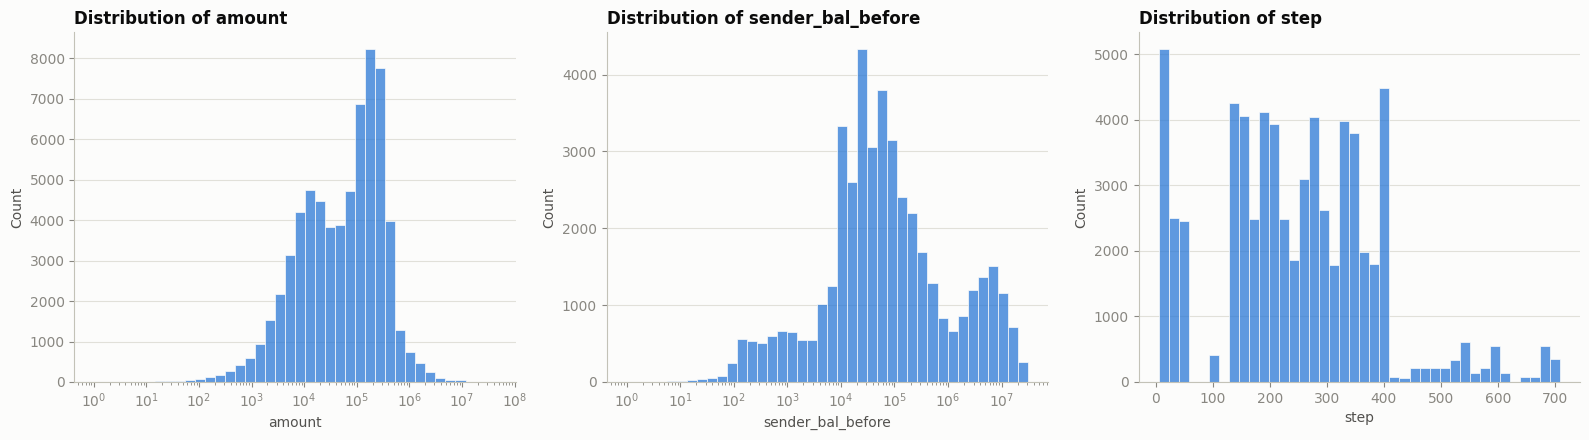

amount: median=$73,189.20, mean=$172,646.05, 99th pct=$1,562,840.21, max=$43,638,406.64
32.9% of sampled transactions have sender_bal_before == 0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_distribution(sample_df[sample_df["amount"] > 0], "amount", ax=axes[0], log_scale=True, kde=False)
plot_distribution(sample_df[sample_df["sender_bal_before"] > 0], "sender_bal_before", ax=axes[1], log_scale=True, kde=False)
plot_distribution(sample_df, "step", ax=axes[2], kde=False)
fig.tight_layout()
plt.show()

print(f"amount: median=${sample_df['amount'].median():,.2f}, mean=${sample_df['amount'].mean():,.2f}, "
      f"99th pct=${sample_df['amount'].quantile(0.99):,.2f}, max=${sample_df['amount'].max():,.2f}")
zero_bal_before = (sample_df["sender_bal_before"] == 0).mean() * 100
print(f"{zero_bal_before:.1f}% of sampled transactions have sender_bal_before == 0")

## Correlation heatmap

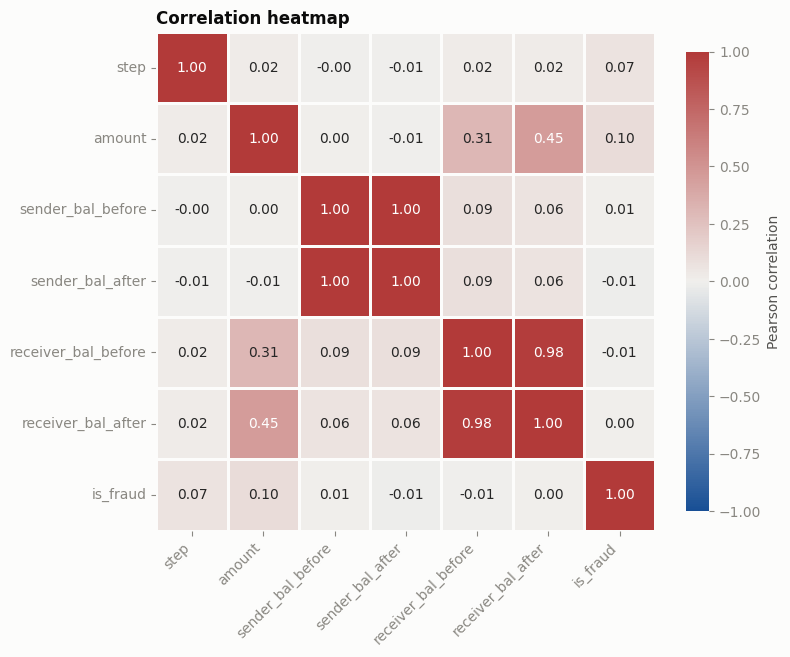

Correlation of is_fraud with other numeric fields:
amount                 0.102
step                   0.070
sender_bal_before      0.007
receiver_bal_after     0.001
receiver_bal_before   -0.007
sender_bal_after      -0.014


In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_correlation_heatmap(sample_df, columns=NUMERIC_COLS, ax=ax)
plt.show()

corr = sample_df[NUMERIC_COLS].corr()
print("Correlation of is_fraud with other numeric fields:")
print(corr["is_fraud"].drop("is_fraud").sort_values(ascending=False).round(3).to_string())

## Fraud rate by transaction type

,txn_type,total_txns,fraud_txns,fraud_rate_pct
0,TRANSFER,532909,4097,0.7688
1,CASH_OUT,2237500,4116,0.1840
2,CASH_IN,1399284,0,0.0000
3,DEBIT,41432,0,0.0000
4,PAYMENT,2151495,0,0.0000


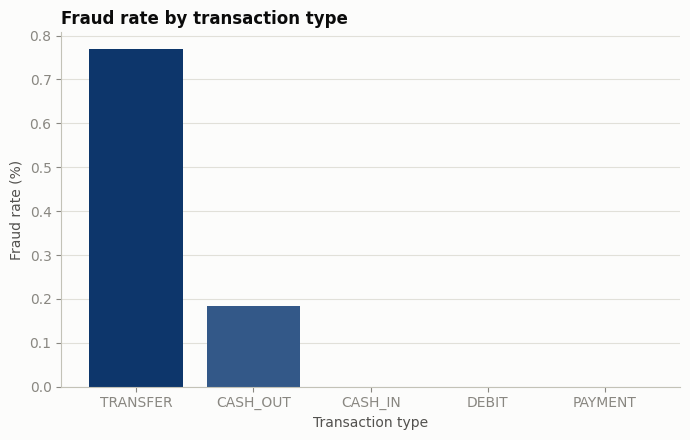

TRANSFER has the highest fraud rate: 0.7688% (4,097 of 532,909 txns)
Transaction types with zero observed fraud: ['CASH_IN', 'DEBIT', 'PAYMENT']


In [5]:
by_type = pd.read_sql("""
    SELECT txn_type, COUNT(*) AS total_txns, SUM(is_fraud) AS fraud_txns,
           ROUND(100.0 * SUM(is_fraud) / COUNT(*), 4) AS fraud_rate_pct
    FROM finsight.transactions GROUP BY txn_type ORDER BY fraud_rate_pct DESC;
""", engine)
display(by_type)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = sequential_shades(len(by_type))[::-1]
ax.bar(by_type["txn_type"], by_type["fraud_rate_pct"], color=colors)
ax.set_title("Fraud rate by transaction type", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Transaction type")
ax.set_ylabel("Fraud rate (%)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

top = by_type.iloc[0]
print(f"{top['txn_type']} has the highest fraud rate: {top['fraud_rate_pct']}% ({top['fraud_txns']:,} of {top['total_txns']:,} txns)")
zero_types = by_type[by_type["fraud_rate_pct"] == 0]["txn_type"].tolist()
print(f"Transaction types with zero observed fraud: {zero_types}")

## Fraud rate by balance-drain pattern (TRANSFER / CASH_OUT only)

A classic PaySim fraud signature: the sender's account is emptied in a single transaction (`sender_bal_after == 0` and `amount == sender_bal_before`). Restricted to the two transaction types where fraud actually occurs.

,pattern,total_txns,fraud_txns,fraud_rate_pct
0,Account fully drained,8008,8008,100.0000
1,Not fully drained,2762401,205,0.0074


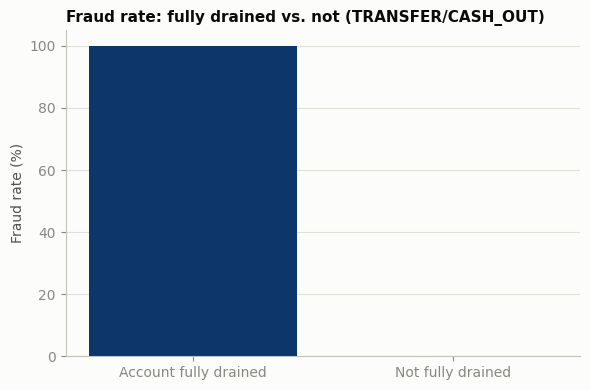

Fully-drained transactions are 13513.5x more likely to be fraud (100.0% vs 0.0074%)
Fully-drained transactions make up 0.29% of TRANSFER/CASH_OUT volume but 97.5% of their fraud


In [6]:
by_drain = pd.read_sql("""
    SELECT
        CASE WHEN sender_bal_before > 0 AND sender_bal_after = 0 AND amount = sender_bal_before
             THEN 'Account fully drained' ELSE 'Not fully drained' END AS pattern,
        COUNT(*) AS total_txns, SUM(is_fraud) AS fraud_txns,
        ROUND(100.0 * SUM(is_fraud) / COUNT(*), 4) AS fraud_rate_pct
    FROM finsight.transactions
    WHERE txn_type IN ('TRANSFER','CASH_OUT')
    GROUP BY pattern ORDER BY fraud_rate_pct DESC;
""", engine)
display(by_drain)

fig, ax = plt.subplots(figsize=(6, 4))
colors = sequential_shades(len(by_drain))[::-1]
ax.bar(by_drain["pattern"], by_drain["fraud_rate_pct"], color=colors)
ax.set_title("Fraud rate: fully drained vs. not (TRANSFER/CASH_OUT)", loc="left", fontsize=11, fontweight="bold")
ax.set_ylabel("Fraud rate (%)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

drained = by_drain[by_drain["pattern"] == "Account fully drained"].iloc[0]
not_drained = by_drain[by_drain["pattern"] == "Not fully drained"].iloc[0]
lift = drained["fraud_rate_pct"] / not_drained["fraud_rate_pct"]
print(f"Fully-drained transactions are {lift:.1f}x more likely to be fraud "
      f"({drained['fraud_rate_pct']}% vs {not_drained['fraud_rate_pct']}%)")
print(f"Fully-drained transactions make up {100*drained['total_txns']/(drained['total_txns']+not_drained['total_txns']):.2f}% "
      f"of TRANSFER/CASH_OUT volume but {100*drained['fraud_txns']/(drained['fraud_txns']+not_drained['fraud_txns']):.1f}% of their fraud")

## Key Insights

1. **Fraud is extremely rare - a severe class-imbalance problem**: only 8,213 of 6,362,620 transactions (0.129%) are fraudulent. Any model here needs precision/recall framing, not accuracy, and a naive "always legitimate" classifier would already be 99.87% "accurate" while catching zero fraud.
2. **Fraud is entirely confined to two transaction types**: TRANSFER (0.7688% fraud rate) and CASH_OUT (0.1840%). CASH_IN, DEBIT, and PAYMENT have zero observed fraud across their combined 3.59M transactions - fraud detection effort should focus exclusively on TRANSFER/CASH_OUT.
3. **"Account fully drained" is a near-perfect fraud signal**: of the 8,008 TRANSFER/CASH_OUT transactions where the sender's balance goes from some positive amount to exactly zero in one step, 100% are fraudulent. This pattern is only 0.29% of TRANSFER/CASH_OUT volume but accounts for 97.5% of all fraud in those types - a 13,500x fraud-rate lift over non-drained transactions.
4. **Raw numeric fields barely correlate with is_fraud** - the strongest single-field correlation is `amount` at r=0.10; balance fields are all under r=0.02. Fraud isn't a magnitude effect, it's a structural pattern (a specific combination of before/after/amount), which is exactly why the engineered "fully drained" feature above outperforms any raw column by orders of magnitude.
5. **amount and sender_bal_before are both heavily right-skewed**, needing a log scale to read: amount has a median of $73,189 but a 99th percentile of $1.56M and a max of $43.6M. About 32.9% of sampled transactions start from a zero sender balance (expected for CASH_IN/PAYMENT inflows).
